# SEED Experiments

### Dependencies

In [1]:
# Added for offline HF access
import os
# os.environ["TRANSFORMERS_OFFLINE"] = "1"
# os.environ["HF_DATASETS_OFFLINE"] = "1"

# # Disable Hugging Face Hub internet access
# os.environ["HF_HUB_OFFLINE"] = "1"
# os.environ["TRANSFORMERS_OFFLINE"] = "1"

import random

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import re
import math
import torch
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn


import seaborn as sns
from sklearn.metrics import *
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.patches import Patch
from transformers import AutoModel
from datetime import datetime, timedelta
from transformers import get_cosine_schedule_with_warmup
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, DistilBertModel
from transformers import BertTokenizer, DistilBertTokenizer, BertTokenizerFast
from transformers import AutoTokenizer, AutoModelForMaskedLM
from transformers import BertModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
LOG_DIR   = '/kaggle/working/logs'
os.makedirs(LOG_DIR, exist_ok=True)

# Data Merging and Exploration

In [6]:
# !git clone https://github.com/AdityaLab/Time-MMD.git
# !git clone https://github.com/AdityaLab/MM-TSFlib.git  

In [7]:
# numeric_df = pd.read_csv("/kaggle/working/Time-MMD/numerical/Health_US/Health_US.csv")
# numeric_df

In [8]:
# numeric_df.isnull().sum().sort_values()

In [9]:
# Time-MMD Dataset
# numeric_df.info()

- ### Health_report.csv:

This contains text from official sources like CDC weekly influenza surveillance reports (1999–present) and annual flu season studies/news (2019–present). Each row represents a textual entry (with columns like start_date, end_date, fact, pred) tied to a specific time interval (weekly in most cases). "Fact" is objective info (e.g., current statistics), and "pred" is predictions/insights (e.g., future trends).

- ### Health_search.csv:
This contains text from web search results generated weekly using keywords like "influenza" and "epidemic" (from general sources). It has the same column structure but from a different origin—more dynamic and potentially noisier, with broader coverage (e.g., news snippets).

In [10]:
# report_df = pd.read_csv("/kaggle/working/Time-MMD/textual/Health_US/Health_US_report.csv")
# search_df = pd.read_csv("/kaggle/working/Time-MMD/textual/Health_US/Health_US_search.csv")

In [11]:
# report_df.head(3)

In [12]:
# search_df.head(3)

In [13]:
# It is likely that we dont need the "end_date"
# search_df.drop(["Unnamed: 0"], axis=1, inplace=True)
# search_df.head(3)

In [14]:
# same for the report_df
# report_df.drop(["Unnamed: 0"], axis=1, inplace=True)
# report_df.head(3)

In [15]:
# text_df = pd.concat([report_df, search_df], ignore_index=True)
# text_df.head(3)

In [16]:
# print(f"report data size: {report_df.shape}")
# print(f"search data size: {search_df.shape}")
# print(f"merged data size: {text_df.shape}")

### New Data

In [17]:
# new cell
df = pd.read_csv("/kaggle/input/datasets/mohammadhossein77/ili-data/US_FLURATIO_Week.csv")
df.head(3)

,date,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,...,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,Final_Search_2,Final_Search_4,Final_Search_6,Final_Output
0,9/29/1997,9/29/1997,10/5/1997,National,X,1997,40,1.10148,1.21686,179,...,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,10/6/1997,10/6/1997,10/12/1997,National,X,1997,41,1.20007,1.28064,199,...,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,10/13/1997,10/13/1997,10/19/1997,National,X,1997,42,1.37876,1.23906,228,...,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [18]:
# df["Final_Search_2"].iloc[1:2].values[0]

In [19]:
# df["Final_Search_4"].iloc[1:2].values[0]

In [20]:
# df["Final_Search_6"].iloc[1:2].values[0]

In [21]:
# df["Final_Output"].iloc[1:2].values[0]

In [22]:
# len(df["Final_Search_2"].iloc[1:2].values[0])

In [23]:
# len(df["Final_Search_4"].iloc[1:2].values[0])

In [24]:
# len(df["Final_Search_6"].iloc[1:2].values[0])

In [25]:
# len(df["Final_Search_6"].head(1)[0])

In [26]:
# we will only keep the finaL_search_2 
text_df = pd.DataFrame()
text_df["facts"] = df["Final_Search_6"]
text_df.head()

,facts
0,Available facts are as follows: 1997-09-22: Za...
1,Available facts are as follows: 1997-09-29: Th...
2,Available facts are as follows: 1997-10-06: Th...
3,Available facts are as follows: 1997-10-13: Ob...
4,Available facts are as follows: 1997-10-20: Th...


In [27]:
# df.columns

In [28]:
# df["Final_Output"].iloc[:1].values[0]

In [29]:
text_df["preds"] = df["Final_Output"]
text_df.head(3)

,facts,preds
0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [30]:
text_df.shape

(1389, 2)

In [31]:
numeric_df = pd.DataFrame()
numeric_df = df.iloc[:, :-4]
numeric_df.head(3)

,date,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,...,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std
0,9/29/1997,9/29/1997,10/5/1997,National,X,1997,40,1.10148,1.21686,179,...,157,205,X,29,570,192,46842,1997-40,0.0,0.0
1,10/6/1997,10/6/1997,10/12/1997,National,X,1997,41,1.20007,1.28064,199,...,151,242,X,23,615,191,48023,1997-41,0.0,0.0
2,10/13/1997,10/13/1997,10/19/1997,National,X,1997,42,1.37876,1.23906,228,...,153,266,X,34,681,219,54961,1997-42,0.0,0.0


In [32]:
del df

In [33]:
numeric_df.drop(["date"], axis=1, inplace=True)
numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])
numeric_df['end_date'] = pd.to_datetime(numeric_df['end_date'])
numeric_df.head(3)

,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std
0,1997-09-29,1997-10-05,National,X,1997,40,1.10148,1.21686,179,X,157,205,X,29,570,192,46842,1997-40,0.0,0.0
1,1997-10-06,1997-10-12,National,X,1997,41,1.20007,1.28064,199,X,151,242,X,23,615,191,48023,1997-41,0.0,0.0
2,1997-10-13,1997-10-19,National,X,1997,42,1.37876,1.23906,228,X,153,266,X,34,681,219,54961,1997-42,0.0,0.0


In [34]:
text_df.head(3)

,facts,preds
0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [35]:
print(f"text_df shape: {text_df.shape}\nnumeric_df shape: {numeric_df.shape}")

text_df shape: (1389, 2)
numeric_df shape: (1389, 20)


In [36]:
merged_df = pd.concat([numeric_df, text_df], axis=1)
merged_df.head(3)

,start_date,end_date,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,OT,AGE 0-4,AGE 25-49,...,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,facts,preds
0,1997-09-29,1997-10-05,National,X,1997,40,1.10148,1.21686,179,X,...,X,29,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p..."
1,1997-10-06,1997-10-12,National,X,1997,41,1.20007,1.28064,199,X,...,X,23,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ..."
2,1997-10-13,1997-10-19,National,X,1997,42,1.37876,1.23906,228,X,...,X,34,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ..."


In [37]:
merged_df.isnull().sum()

start_date            0
end_date              0
REGION TYPE           0
REGION                0
YEAR                  0
WEEK                  0
% WEIGHTED ILI        0
OT                    0
AGE 0-4               0
AGE 25-49             0
AGE 25-64             0
AGE 5-24              0
AGE 50-64             0
AGE 65                0
ILITOTAL              0
NUM. OF PROVIDERS     0
TOTAL PATIENTS        0
YEAR_WEEK             0
prior_history_avg     0
prior_history_std    53
facts                 0
preds                 0
dtype: int64

### CoT module

In [38]:
# import pandas as pd
# import requests
# import json
# from tqdm import tqdm
# import time


# # LM Studio server configuration (default settings)
# LM_STUDIO_URL = "http://localhost:1234/v1/chat/completions"


# def summarize_with_lmstudio(text, model_name="model_name"):
#     """
#     Summarize text using your local LM Studio model
#     Replace "your-model-name" with what you see in LM Studio
#     """
#     if pd.isna(text) or len(str(text).strip()) < 50:
#         return str(text)[:384]
    
#     # Limit input to avoid overwhelming the model
#     text = str(text)[:3500]
    
#     # The prompt - tailored for your influenza prediction task
#     prompt = f"""You are a text summarizer for a health prediction system.

# TASK: Summarize this influenza/flu news search report concisely but keep ALL key information that helps the model to predict influenza rate in future.

# WHAT TO KEEP:
# - Specific dates and their key events (e.g., "1997-09-22: Zanamivir treatment...")
# - Mortality rates, infection percentages, any numbers that is relevant
# - Outbreak locations and patterns
# - Treatments, vaccines, antivirals mentioned
# - Prevention strategies and surveillance info
# - At-risk populations (seniors, age groups, etc.)
# - Any temporal trends or changes over time

# WHAT TO REMOVE:
# - Source citations like "[Source: ...]"
# - Meta-statements like "Objective facts about..."
# - Redundant or repetitive information

# FORMAT: Keep date entries when present. Keep it under 380 words (so BERT can process it with max_len not more than 384).

# TEXT TO SUMMARIZE:
# {text}

# CONCISE SUMMARY WITH KEY PREDICTIVE INFORMATION:"""

#     # Prepare the API request (OpenAI-compatible format) [citation:8]
#     payload = {
#         "model": model_name,  # Replace with your actual model name
#         "messages": [
#             {"role": "user", "content": prompt}
#         ],
#         "temperature": 0.3,  # Lower = more focused, factual
#         "max_tokens": 500,   # Generates ~300-400 words
#         "top_p": 0.95
#     }
    
#     try:
#         response = requests.post(
#             LM_STUDIO_URL,
#             headers={"Content-Type": "application/json"},
#             json=payload,
#             timeout=60  # 60 seconds timeout
#         )
        
#         if response.status_code == 200:
#             result = response.json()
#             summary = result['choices'][0]['message']['content']
            
#             # Ensure under BERT's 384 token limit (~550 chars)
#             if len(summary) > 560:
#                 summary = summary[:560].rsplit(' ', 1)[0]
            
#             return summary
#         else:
#             print(f"API Error {response.status_code}: {response.text}")
#             return text[:384]  # Fallback to truncation
            
#     except requests.exceptions.Timeout:
#         print("Request timed out - model might be slow")
#         return text[:384]
#     except Exception as e:
#         print(f"Error: {e}")
#         return text[:384]




In [39]:
# # lets see ....
# df = merged_df
# model_name = "google/gemma-3-4b"  


# # Apply summarization to your text column
# print("\nSummarizing all rows...")
# tqdm.pandas(desc="Processing")
# df['summarized_text'] = df['facts'].progress_apply(
#     lambda x: summarize_with_lmstudio(x, model_name)
# )


# # Save the results
# output_file = "summarized_data.csv"
# df.to_csv(output_file, index=False)
# print(f"\nDone! Saved to {output_file}")

# # Check the results
# print("\nSummary Statistics:")
# print(f"Average summary length: {df['summarized_text'].str.len().mean():.0f} characters")
# print(f"Max summary length: {df['summarized_text'].str.len().max()} characters")

# # Show an example
# print("\nExample output (first row):")
# print("-" * 50)
# print(df.iloc[0]['summarized_text'][:500])
# print("-" * 50)

### End of the modifications made to the code

In [40]:
## Align on dates 
# numeric_df['start_date'] = pd.to_datetime(numeric_df['start_date'])  
# text_df['start_date'] = pd.to_datetime(text_df['start_date'])
# merged_df = pd.merge(numeric_df, text_df, on='start_date', how='left').fillna('')  # Fill missing text with empty

In [41]:
# lets drop the facts column. 
# Considering that the CMA module is going to calculate an attention between two modalities
# and the LLM already used the facts to generate preds, there seems to be no point in using 
# summarized facts as an input to the CMA. In fact, I suspect that it would introduce noise
# in text signal.

# merged_df.drop(["facts"], axis=1, inplace=True)

In [42]:
# merged_df[["AGE 25-49", # object
#            "AGE 50-64", # object
#            "AGE 25-64" # this one seeems to be the sum of the previous ones (object)
#           ]]

In [43]:
merged_df.isna().sum()

start_date            0
end_date              0
REGION TYPE           0
REGION                0
YEAR                  0
WEEK                  0
% WEIGHTED ILI        0
OT                    0
AGE 0-4               0
AGE 25-49             0
AGE 25-64             0
AGE 5-24              0
AGE 50-64             0
AGE 65                0
ILITOTAL              0
NUM. OF PROVIDERS     0
TOTAL PATIENTS        0
YEAR_WEEK             0
prior_history_avg     0
prior_history_std    53
facts                 0
preds                 0
dtype: int64

In [44]:
# Update ----- "Week" feature should be defined in a manner that reflects its cyclic nature
merged_df["WEEK_sin"] = np.sin(2 * np.pi * (merged_df["WEEK"]/52))
merged_df["WEEK_cos"] = np.cos(2 * np.pi * (merged_df["WEEK"]/52))

merged_df.drop(["WEEK"], axis=1, inplace=True)
merged_df.head(3)

,start_date,end_date,REGION TYPE,REGION,YEAR,% WEIGHTED ILI,OT,AGE 0-4,AGE 25-49,AGE 25-64,...,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,YEAR_WEEK,prior_history_avg,prior_history_std,facts,preds,WEEK_sin,WEEK_cos
0,1997-09-29,1997-10-05,National,X,1997,1.10148,1.21686,179,X,157,...,570,192,46842,1997-40,0.0,0.0,Available facts are as follows: 1997-09-22: Za...,"Based on the provided textual information, I p...",-0.992709,0.120537
1,1997-10-06,1997-10-12,National,X,1997,1.20007,1.28064,199,X,151,...,615,191,48023,1997-41,0.0,0.0,Available facts are as follows: 1997-09-29: Th...,"Based on the provided textual information, my ...",-0.970942,0.239316
2,1997-10-13,1997-10-19,National,X,1997,1.37876,1.23906,228,X,153,...,681,219,54961,1997-42,0.0,0.0,Available facts are as follows: 1997-10-06: Th...,"Based on the available textual information, I ...",-0.935016,0.354605


In [45]:
# # New cyclic features ....
# def add_trend_features(df):
#     df = df.copy()
#     # 1. Week-over-week change
#     # df["OT_diff_1"] = df["OT"].diff() # positive -> outbreak increasing (Vice-Versa)
    
#     # 2. Rooling average of OT rate
#     # df["OT_roll_mean_3"] = df["OT"].rolling(window=3).mean()
#     df["OT_roll_mean_9"] = df["OT"].rolling(window=9).mean()
    
#     # 3. Rooling standard deviation of OT rate
#     # df["OT_roll_std_3"] = df["OT"].rolling(window=3).std()
#     df["OT_roll_std_9"] = df["OT"].rolling(window=9).std()
    
#     # 4. Momentun rate
#     # df["OT_momentum_3"] = df["OT"] - df["OT"].shift(3)
#     # df["OT_momentum_6"] = df["OT"] - df["OT"].shift(6)

#     # 5. Relative Surge Feature
#     # df["OT_relative_6"] = (df["OT"] / df["OT_roll_mean_6"] + 1e-6) ## to not introduce new feature, I decided to rewrite it
#     # df["OT_relative_6"] = (df["OT"] / (df["OT"].rooling(window=6).mean() + 1e-6)) 

#     # 6. Acceleration feature
#     # df["OT_acceleration"] = df["OT_diff_1"].diff(1) 
#     df = df.fillna(0)

#     return df



In [46]:
merged_df["REGION TYPE"].value_counts()

REGION TYPE
National    1389
Name: count, dtype: int64

In [47]:
merged_df["REGION"].value_counts()

REGION
X    1389
Name: count, dtype: int64

In [48]:
merged_df["YEAR_WEEK"].value_counts()

YEAR_WEEK
2024-19    1
1997-40    1
1997-41    1
1997-42    1
1997-43    1
          ..
1998-3     1
1998-4     1
1998-5     1
1998-6     1
1998-7     1
Name: count, Length: 1389, dtype: int64

In [49]:
merged_df.drop(["REGION TYPE", "REGION", "YEAR_WEEK"], axis=1, inplace=True)

In [50]:
merged_df.columns

Index(['start_date', 'end_date', 'YEAR', '% WEIGHTED ILI', 'OT', 'AGE 0-4',
       'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'prior_history_avg',
       'prior_history_std', 'facts', 'preds', 'WEEK_sin', 'WEEK_cos'],
      dtype='object')

In [51]:
merged_df.isna().sum()

start_date            0
end_date              0
YEAR                  0
% WEIGHTED ILI        0
OT                    0
AGE 0-4               0
AGE 25-49             0
AGE 25-64             0
AGE 5-24              0
AGE 50-64             0
AGE 65                0
ILITOTAL              0
NUM. OF PROVIDERS     0
TOTAL PATIENTS        0
prior_history_avg     0
prior_history_std    53
facts                 0
preds                 0
WEEK_sin              0
WEEK_cos              0
dtype: int64

In [52]:
merged_df.drop(["prior_history_std", "prior_history_avg"], axis=1, inplace=True)
merged_df.isna().sum()

start_date           0
end_date             0
YEAR                 0
% WEIGHTED ILI       0
OT                   0
AGE 0-4              0
AGE 25-49            0
AGE 25-64            0
AGE 5-24             0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
facts                0
preds                0
WEEK_sin             0
WEEK_cos             0
dtype: int64

In [53]:
cols = merged_df.columns
cols

Index(['start_date', 'end_date', 'YEAR', '% WEIGHTED ILI', 'OT', 'AGE 0-4',
       'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'facts', 'preds', 'WEEK_sin',
       'WEEK_cos'],
      dtype='object')

In [54]:
# Updated ----------------------
# start_date, end_date, REGTION_TYPE
num_features = ['YEAR',
                "WEEK_sin",
                "WEEK_cos",
                '% WEIGHTED ILI',
                'AGE 0-4',
                'AGE 5-24',
                'AGE 25-49',
                'AGE 25-64',
                'AGE 50-64',
                'AGE 65',
                'ILITOTAL',
                'NUM. OF PROVIDERS',
                'TOTAL PATIENTS'
               ]

print(f"Number of features: {len(num_features)}") # should be 13
print(num_features)


Number of features: 13
['YEAR', 'WEEK_sin', 'WEEK_cos', '% WEIGHTED ILI', 'AGE 0-4', 'AGE 5-24', 'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS']


In [55]:
merged_df.isna().sum()

start_date           0
end_date             0
YEAR                 0
% WEIGHTED ILI       0
OT                   0
AGE 0-4              0
AGE 25-49            0
AGE 25-64            0
AGE 5-24             0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
facts                0
preds                0
WEEK_sin             0
WEEK_cos             0
dtype: int64

In [56]:
# age_cols = ['AGE 25-49', 'AGE 50-64', 'AGE 25-64'] 
# now do the below code for all columns, not just those columns mentioned above
cols = merged_df.columns
merged_df[cols] = merged_df[cols].replace('X', np.nan) # for all columns
print(merged_df[cols].isna().sum())

start_date             0
end_date               0
YEAR                   0
% WEIGHTED ILI         0
OT                     0
AGE 0-4                0
AGE 25-49            532
AGE 25-64            762
AGE 5-24               0
AGE 50-64            532
AGE 65                 0
ILITOTAL               0
NUM. OF PROVIDERS      0
TOTAL PATIENTS         0
facts                  0
preds                  0
WEEK_sin               0
WEEK_cos               0
dtype: int64


In [57]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   start_date         1389 non-null   datetime64[ns]
 1   end_date           1389 non-null   datetime64[ns]
 2   YEAR               1389 non-null   int64         
 3   % WEIGHTED ILI     1389 non-null   float64       
 4   OT                 1389 non-null   float64       
 5   AGE 0-4            1389 non-null   int64         
 6   AGE 25-49          857 non-null    object        
 7   AGE 25-64          627 non-null    object        
 8   AGE 5-24           1389 non-null   int64         
 9   AGE 50-64          857 non-null    object        
 10  AGE 65             1389 non-null   int64         
 11  ILITOTAL           1389 non-null   int64         
 12  NUM. OF PROVIDERS  1389 non-null   int64         
 13  TOTAL PATIENTS     1389 non-null   int64         
 14  facts   

In [58]:
merged_df[num_features] = merged_df[num_features].apply(pd.to_numeric, errors='coerce') # just the numeric ones
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   start_date         1389 non-null   datetime64[ns]
 1   end_date           1389 non-null   datetime64[ns]
 2   YEAR               1389 non-null   int64         
 3   % WEIGHTED ILI     1389 non-null   float64       
 4   OT                 1389 non-null   float64       
 5   AGE 0-4            1389 non-null   int64         
 6   AGE 25-49          857 non-null    float64       
 7   AGE 25-64          627 non-null    float64       
 8   AGE 5-24           1389 non-null   int64         
 9   AGE 50-64          857 non-null    float64       
 10  AGE 65             1389 non-null   int64         
 11  ILITOTAL           1389 non-null   int64         
 12  NUM. OF PROVIDERS  1389 non-null   int64         
 13  TOTAL PATIENTS     1389 non-null   int64         
 14  facts   

# Data Preprocessing

In [59]:
merged_df.sort_values('start_date', inplace=True)

In [60]:
# Chronological split: 80% train, 10% val, 10% test
train_size = int(len(merged_df) * 0.8)
val_size = int(len(merged_df) * 0.1)

train_df = merged_df.iloc[:train_size]
val_df = merged_df.iloc[train_size:train_size + val_size]
test_df = merged_df.iloc[train_size + val_size:]

print(f'Train: {len(train_df)*100/len(merged_df)}\nVal: {len(val_df)*100/len(merged_df)}\nTest: {len(test_df)*100/len(merged_df)}')

Train: 79.98560115190784
Val: 9.935205183585314
Test: 10.079193664506839


In [61]:
# Same Logic as before, but on scale of data frames
for df in [train_df, val_df, test_df]:
    mask_split_nan = df['AGE 25-49'].isna() & df['AGE 50-64'].isna() & ~df['AGE 25-64'].isna()
    df.loc[mask_split_nan, 'AGE 25-49'] = df.loc[mask_split_nan, 'AGE 25-64'] * 0.6
    df.loc[mask_split_nan, 'AGE 50-64'] = df.loc[mask_split_nan, 'AGE 25-64'] * 0.4
    
    mask_combined_nan = ~df['AGE 25-49'].isna() & ~df['AGE 50-64'].isna() & df['AGE 25-64'].isna()
    df.loc[mask_combined_nan, 'AGE 25-64'] = df.loc[mask_combined_nan, 'AGE 25-49'] + df.loc[mask_combined_nan, 'AGE 50-64']

In [62]:
print(merged_df.isna().sum())

start_date           0
end_date             0
YEAR                 0
% WEIGHTED ILI       0
OT                   0
AGE 0-4              0
AGE 25-49            0
AGE 25-64            0
AGE 5-24             0
AGE 50-64            0
AGE 65               0
ILITOTAL             0
NUM. OF PROVIDERS    0
TOTAL PATIENTS       0
facts                0
preds                0
WEEK_sin             0
WEEK_cos             0
dtype: int64


In [63]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   start_date         1389 non-null   datetime64[ns]
 1   end_date           1389 non-null   datetime64[ns]
 2   YEAR               1389 non-null   int64         
 3   % WEIGHTED ILI     1389 non-null   float64       
 4   OT                 1389 non-null   float64       
 5   AGE 0-4            1389 non-null   int64         
 6   AGE 25-49          1389 non-null   float64       
 7   AGE 25-64          1389 non-null   float64       
 8   AGE 5-24           1389 non-null   int64         
 9   AGE 50-64          1389 non-null   float64       
 10  AGE 65             1389 non-null   int64         
 11  ILITOTAL           1389 non-null   int64         
 12  NUM. OF PROVIDERS  1389 non-null   int64         
 13  TOTAL PATIENTS     1389 non-null   int64         
 14  facts   

In [64]:
num_features

['YEAR',
 'WEEK_sin',
 'WEEK_cos',
 '% WEIGHTED ILI',
 'AGE 0-4',
 'AGE 5-24',
 'AGE 25-49',
 'AGE 25-64',
 'AGE 50-64',
 'AGE 65',
 'ILITOTAL',
 'NUM. OF PROVIDERS',
 'TOTAL PATIENTS']

In [65]:
# # Update -------------------------
# train_df = add_trend_features(train_df)
# val_df = add_trend_features(val_df)
# test_df = add_trend_features(test_df)

In [66]:
scaler = MinMaxScaler()
train_df[num_features] = scaler.fit_transform(train_df[num_features])
val_df[num_features] = scaler.transform(val_df[num_features])
test_df[num_features] = scaler.transform(test_df[num_features])

# Saved for later (inverse transform predictions)
joblib.dump(scaler, '/kaggle/working/feature_scaler.pkl')


# scaling targets (Updated to prevent leakage)
target_scaler = MinMaxScaler()
train_df["OT"] = target_scaler.fit_transform(train_df["OT"].values.reshape(-1,1)).flatten()
val_df["OT"] = target_scaler.transform(val_df["OT"].values.reshape(-1,1)).flatten()
test_df["OT"] = target_scaler.transform(test_df["OT"].values.reshape(-1,1)).flatten()

joblib.dump(target_scaler, '/kaggle/working/target_scaler.pkl')

# Updated
num_features.append("OT")

In [67]:
print(f"numerical features:\n{num_features}")

numerical features:
['YEAR', 'WEEK_sin', 'WEEK_cos', '% WEIGHTED ILI', 'AGE 0-4', 'AGE 5-24', 'AGE 25-49', 'AGE 25-64', 'AGE 50-64', 'AGE 65', 'ILITOTAL', 'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'OT']


In [68]:
print(f"columns:{merged_df.columns}\nshape:{merged_df.shape}")

columns:Index(['start_date', 'end_date', 'YEAR', '% WEIGHTED ILI', 'OT', 'AGE 0-4',
       'AGE 25-49', 'AGE 25-64', 'AGE 5-24', 'AGE 50-64', 'AGE 65', 'ILITOTAL',
       'NUM. OF PROVIDERS', 'TOTAL PATIENTS', 'facts', 'preds', 'WEEK_sin',
       'WEEK_cos'],
      dtype='object')
shape:(1389, 18)


In [69]:
# Same functionality as before but with Horizon & Look Back

def create_sequences(df, lookback, horizon):
    df = df.sort_values('start_date').reset_index(drop=True)  # Ensure order
    X_num, X_text, y=[], [], []
        
    for i in range(len(df) - lookback - horizon + 1):
        # 1. get the numerical features
        num_seq = df[num_features].iloc[i:i+lookback].values # (36,14)
        
        # 2. textuals too
        # Updated: Changing the texual contents into a list of values
        # text_seq = (df['facts'].iloc[i:i+lookback] + ' ' + df['preds'].iloc[i:i+lookback]).to_list()  # update: we no longer need the facts
        # text_seq = (df['preds'].iloc[i:i+lookback] + ' ' + df['facts'].iloc[i:i+lookback]).to_list() # to make sure facts survives the textual stream
        # text_seq = (df['preds'].iloc[i:i+lookback]).to_list()
        text_seq = (df['facts'].iloc[i:i+lookback]).to_list()
        
        # 3. and the OT (target)
        target = df['OT'].iloc[i+lookback:i+lookback+horizon].values # (12,)

        X_num.append(num_seq)
        X_text.append(text_seq)
        y.append(target)
        
    return np.array(X_num), np.array(X_text), np.array(y)
        

In [70]:
# Train / Val / Test splitting
lookback = 36 # Default of Time-MMD
horizon = 12  # predict 12 weeks at once

# X_num_train, X_text_train, y_train = create_sequences(train_df, lookback, horizon)
# X_num_val, X_text_val, y_val = create_sequences(val_df, lookback, horizon)
# X_num_test, X_text_test, y_test = create_sequences(test_df, lookback, horizon)

# Update --------
# Prepend the tail of the previous split so the first sequence 
# in val/test has a full 36-week lookback drawn from real history
val_df_full = pd.concat([train_df.iloc[-lookback:], val_df],  ignore_index=True)
test_df_full = pd.concat([val_df.iloc[-lookback:],  test_df], ignore_index=True)

X_num_train, X_text_train, y_train = create_sequences(train_df, lookback, horizon)
X_num_val, X_text_val, y_val = create_sequences(val_df_full, lookback, horizon)
X_num_test, X_text_test, y_test = create_sequences(test_df_full, lookback, horizon)

In [71]:
# Double checking
X_num_train.shape

(1064, 36, 14)

In [72]:
X_text_train.shape

(1064, 36)

In [73]:
# Double checking
y_train.shape

(1064, 12)

In [74]:

def tokenize_headlines(sequences, max_len=256, tokenizer=None): 
    """Added the functionality to handle various tokenizers and also made the caching mechanism faster"""
    if tokenizer is None:
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  
    
    tokenized = []
    for sample in tqdm(sequences): 
        sample = sample.tolist()
        # sample: list of 36 weeks       
        enc = tokenizer(
            sample,                      # batch of 36 strings
            max_length = max_len,
            padding = 'max_length',
            truncation = True,
            return_tensors = 'pt'
            )

        tokenized.append({
            'input_ids': enc['input_ids'],
            'attention_mask': enc['attention_mask']
        })
        
    return tokenized 
  

## Dataset Creation

In [75]:
X_text_train.shape

(1064, 36)

In [76]:
# # UPDATED: Tokenize all the train, validation, and test sets once
# path = r"/home/user/GPU_enabled/Time-MMD/HF/hub/models--microsoft--BiomedNLP-PubMedBERT-base-uncased-abstract/snapshots/d673b8835373c6fa116d6d8006b33d48734e305d/"

# tokenizer = AutoTokenizer.from_pretrained(path, local_files_only=True)

In [77]:
X_text_train_tokenized = tokenize_headlines(X_text_train, 
                                            # tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
                                            # tokenizer = tokenizer,
                                            # tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
                                            tokenizer = AutoTokenizer.from_pretrained("michiyasunaga/BioLinkBERT-base")
                                           )

X_text_val_tokenized = tokenize_headlines(X_text_val, 
                                          # tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
                                          # tokenizer = tokenizer
                                          # tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
                                          tokenizer = AutoTokenizer.from_pretrained("michiyasunaga/BioLinkBERT-base")
                                         )

X_text_test_tokenized = tokenize_headlines(X_text_test, 
                                           # tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
                                           # tokenizer = tokenizer
                                           # tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
                                           tokenizer = AutoTokenizer.from_pretrained("michiyasunaga/BioLinkBERT-base")
                                          )

config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

100%|██████████| 129/129 [00:06<00:00, 18.63it/s]


In [78]:
class CustomDataset(Dataset):
    """Modified to have a 3D shape output"""
    def __init__(self, numerical_data, tokenized_text_data, targets):
        self.numerical_data = torch.tensor(numerical_data, dtype=torch.float32)          
        self.tokenized_text_data = tokenized_text_data  # List of dicts
        self.targets = torch.tensor(targets, dtype=torch.float32) 


    def __len__(self):
        return len(self.numerical_data)


    def __getitem__(self, idx):
        num = self.numerical_data[idx]  # (36, 14)
        text_input = self.tokenized_text_data[idx]  # Dict: (36, max_len)
        target = self.targets[idx]  # (12,)
        return num, text_input, target



In [79]:
train_dataset = CustomDataset(X_num_train, 
                              X_text_train_tokenized, 
                              y_train)

val_dataset = CustomDataset(X_num_val, 
                            X_text_val_tokenized, 
                            y_val)

test_dataset = CustomDataset(X_num_test, 
                             X_text_test_tokenized,
                             y_test)

In [80]:
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [81]:
# train_dataset[0][1]['input_ids'].shape

# Neural Network Components — TaTS (Texts as Time Series)

**Baseline fidelity notes** (read before running):

1. **Text encoder is frozen.** Per the TaTS paper (arXiv:2502.08942, Eq. 3), the text encoder is used as a fixed, off-the-shelf feature extractor — only the projector MLP and the backbone are trained. This is a deliberate difference from DSA, which fine-tunes the last 8 BioLinkBERT layers. Both use the *same* checkpoint (`michiyasunaga/BioLinkBERT-base`) and the same masked-mean-pooling, so the fusion mechanism — not the text encoder — is the isolated variable between DSA and TaTS.
2. **Instance normalization (RevIN-style `use_norm`) is disabled by default** in all three backbones below. The TaTS paper's own defaults use it, but this project already established that RevIN fails on this epidemic data (lookback statistics create a shortcut that doesn't generalize to test). Overriding it here for consistency with that finding.
3. **`d_mapped=12`** (dimensionality of the projected text channels) is the paper's own default sweep midpoint (range: `{6, 12, 24}`) — cheap to sweep later if needed.
4. Only the BERT/text/naive-sum-fusion parts are removed, since TaTS's fusion is channel concatenation (handled in `TaTSWrapper`), not sum fusion. This means TaTS and the naive-fusion baselines share the *exact same* numerical backbone per architecture — the fusion mechanism is now the only thing that differs between "naive fusion" and "TaTS fusion" for a given backbone.

## Frozen Text Encoder

In [82]:
class TaTSTextEncoder(nn.Module):
    """Frozen text encoder for TaTS, matching Eq. (3) of the TaTS paper:
    e_t = H_text(s_t). Unlike DSA's HeadlineEncoder, this has no learned
    inter-week attention or projection layer -- TaTS keeps the text
    encoder fixed and puts all learned capacity in the (tiny) projector
    MLP instead. Same BioLinkBERT-base checkpoint and masked-mean-pooling
    as DSA's HeadlineEncoder, so the encoder itself is held constant
    across DSA vs. TaTS comparisons.
    """
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("michiyasunaga/BioLinkBERT-base")
        for p in self.bert.parameters():
            p.requires_grad = False
        self.bert.eval()

    @torch.no_grad()
    def forward(self, input_ids, attention_masks):
        """
        input_ids, attention_masks: (B, T, L)
        Returns: (B, T, 768)
        """
        B, T, L = input_ids.shape
        flat_ids = input_ids.view(-1, L)
        flat_mask = attention_masks.view(-1, L)

        out = self.bert(input_ids=flat_ids, attention_mask=flat_mask)
        last_hidden = out.last_hidden_state                       # (B*T, L, 768)

        token_mask = flat_mask.unsqueeze(-1)                      # (B*T, L, 1)
        pooled = (last_hidden * token_mask).sum(dim=1) / token_mask.sum(dim=1).clamp(min=1e-6)

        return pooled.view(B, T, 768)

## Text-to-Channel Projector

In [83]:
class TaTSProjector(nn.Module):
    """Maps per-week text embeddings (B, T, d_text) -> low-dimensional
    auxiliary channels (B, T, d_mapped), per Eq. (4). The paper describes
    this as a 'lightweight three-layer MLP' -- kept deliberately small,
    it is meant to preserve periodicity, not to be expressive."""
    def __init__(self, d_text=768, d_mapped=12, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_text, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, d_mapped)
        )

    def forward(self, text_repr):          # (B, T, d_text)
        return self.net(text_repr)          # (B, T, d_mapped)

## Forecasting Backbones

Each backbone implements `forward(x)` with `x: (B, T, C) -> (B, H, C)`, where `C` is the *augmented* channel count (`14` numerical features + `d_mapped` text channels). TaTS plugs into these completely unmodified -- per the paper, that's the whole point.

In [84]:
# ---------------- DLinear ----------------
# Extracted directly from your dlinear-bert.ipynb DLinearBERT class --
# identical decomposition, linear layers, and official weight init.
# Only the BERT/text/naive-sum-fusion parts are removed (TaTS's fusion is
# channel concatenation, handled in TaTSWrapper, not sum fusion).

class MovingAvg(nn.Module):
    """Official DLinear moving average -- identical to your baseline."""
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end   = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        return x.permute(0, 2, 1)


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class DLinearBackbone(nn.Module):
    def __init__(self, seq_len, horizon, num_channels, kernel_size=25, use_norm=False):
        super().__init__()
        self.use_norm = use_norm  # unused; your baseline has no norm step either (kept for interface consistency)
        self.decomp = SeriesDecomp(kernel_size)
        self.linear_seasonal = nn.Linear(seq_len, horizon)
        self.linear_trend = nn.Linear(seq_len, horizon)

        # Official weight init: uniform 1/seq_len -- matches your baseline exactly
        self.linear_seasonal.weight = nn.Parameter(
            (1 / seq_len) * torch.ones([horizon, seq_len]))
        self.linear_trend.weight = nn.Parameter(
            (1 / seq_len) * torch.ones([horizon, seq_len]))

    def forward(self, x):                    # x: (B, T, C)
        seasonal, trend = self.decomp(x)
        seasonal_out = self.linear_seasonal(seasonal.permute(0, 2, 1))   # (B, C, H)
        trend_out = self.linear_trend(trend.permute(0, 2, 1))            # (B, C, H)
        out = seasonal_out + trend_out                                    # (B, C, H)
        return out.permute(0, 2, 1)                                        # (B, H, C)

In [85]:
# ---------------- PatchTST ----------------
# Extracted directly from your patchtst-bert.ipynb PatchTSTBERT class --
# identical patching, positional-embedding init (trunc_normal_), Pre-LN
# transformer, and 2-layer GELU head. Only BERT/text/naive-fusion removed.
#
# NOTE: your notebook's docstring says "patch_len=6, stride=2 (matches best
# unimodal run)", but the hyperparameter cell actually sets PATCH_LEN=4 --
# the model that produced your 2.9825 reference number ran with patch_len=4.
# Defaults below match what was *actually run*, not the docstring.

class PatchTSTBackbone(nn.Module):
    def __init__(self, seq_len, horizon, num_channels, patch_len=4, stride=2,
                 d_model=128, num_heads=8, num_layers=3, d_ff=256,
                 dropout=0.15, use_norm=False):
        super().__init__()
        self.use_norm = use_norm  # unused; your baseline has no instance-norm step either
        self.num_patches = (seq_len - patch_len) // stride + 1
        self.patch_len = patch_len
        self.stride = stride
        self.num_channels = num_channels

        self.patch_proj = nn.Linear(patch_len, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True   # Pre-LN, matches your baseline
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.num_patches * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

    def forward(self, x):                                # x: (B, T, C)
        B, T, C = x.shape
        x = x.transpose(1, 2)                              # (B, C, T)
        x = x.unfold(dimension=2, size=self.patch_len, step=self.stride)  # (B, C, num_patches, patch_len)
        x = x.reshape(B * C, self.num_patches, self.patch_len)

        x = self.patch_proj(x) + self.pos_emb                # (B*C, num_patches, d_model)
        x = self.transformer(x)                               # (B*C, num_patches, d_model)
        x = self.norm(x)
        x = self.head(x)                                        # (B*C, horizon)

        x = x.reshape(B, C, -1)                                  # (B, C, horizon)
        return x.permute(0, 2, 1)                                 # (B, horizon, C)

In [86]:
# ---------------- iTransformer ----------------
# Extracted directly from your itransformer-bert.ipynb iTransformerBERT
# class -- identical variate embedding, Pre-LN transformer, and 2-layer
# GELU head. Only BERT/text/naive-fusion parts removed.

class iTransformerBackbone(nn.Module):
    def __init__(self, seq_len, horizon, num_channels, d_model=512,
                 num_heads=4, num_layers=3, d_ff=256, dropout=0.15, use_norm=False):
        super().__init__()
        self.use_norm = use_norm  # unused; your baseline has no instance-norm step either
        self.variate_proj = nn.Linear(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True   # Pre-LN, matches your baseline
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, horizon),
        )

    def forward(self, x):                       # x: (B, T, C)
        x = x.transpose(1, 2)                     # (B, C, T)
        x = self.variate_proj(x)                    # (B, C, d_model)
        x = self.transformer(x)                      # (B, C, d_model)
        x = self.norm(x)
        x = self.head(x)                               # (B, C, horizon)
        return x.permute(0, 2, 1)                       # (B, horizon, C)

# Proposed Framework Wrapper

In [87]:
class TaTSWrapper(nn.Module):
    """Texts as Time Series (Li et al., arXiv:2502.08942).
    Implements Eq. (4)-(6): text -> low-dim channels -> concatenated onto
    the numerical series -> fed through an unmodified forecasting backbone
    -> only the target channel's forecast is kept.
    """
    def __init__(self, text_encoder, backbone, d_mapped, target_idx):
        super().__init__()
        self.text_encoder = text_encoder
        self.projector = TaTSProjector(d_text=768, d_mapped=d_mapped)
        self.backbone = backbone
        self.target_idx = target_idx

    def forward(self, input_ids, attention_masks, numerical_features):
        text_repr = self.text_encoder(input_ids, attention_masks)      # (B, T, 768) -- frozen, no_grad internally
        z = self.projector(text_repr)                                   # (B, T, d_mapped)
        U = torch.cat([numerical_features, z], dim=-1)                   # (B, T, 14 + d_mapped)
        out = self.backbone(U)                                           # (B, horizon, 14 + d_mapped)
        forecast = out[:, :, self.target_idx]                             # (B, horizon)
        return forecast

# Training Loop

## Loop Init

In [88]:
## imported for AMP -- same as DSA's loop
from torch.cuda.amp import autocast, GradScaler

epochs = 120
patience = 10
warm_up_epochs = 10
accumulation_steps = 4     # effective batch = 16, matching DSA
d_mapped = 12

target_idx = num_features.index("OT")
print(f"target_idx (within {len(num_features)} channels): {target_idx}")

target_idx (within 14 channels): 13


## Core (parametrized across backbones)

In [89]:
def run_tats_experiment(backbone_name, backbone_ctor,
                         d_mapped=d_mapped, epochs=epochs, patience=patience,
                         warm_up_epochs=warm_up_epochs,
                         proj_lr=1e-3, backbone_lr=1e-4):
    """Trains + evaluates TaTS with the given backbone. Mirrors DSA's
    training loop 1:1 (same AMP/accumulation/cosine-warmup/clip/early-stop
    pattern, same accumulation_steps=4) so the only real difference
    between this and the DSA run is the model itself."""

    sep = '=' * 70
    print(f"\n{sep}\nTraining TaTS + {backbone_name}\n{sep}")

    text_encoder = TaTSTextEncoder().to(device)
    backbone = backbone_ctor(
        seq_len=lookback, horizon=horizon,
        num_channels=len(num_features) + d_mapped
    ).to(device)
    tats_model = TaTSWrapper(text_encoder, backbone, d_mapped, target_idx).to(device)

    mse = nn.MSELoss()
    optimizer = torch.optim.AdamW([
        {'params': tats_model.projector.parameters(), 'lr': proj_lr},
        {'params': tats_model.backbone.parameters(),  'lr': backbone_lr},
    ], weight_decay=1e-4)

    amp_scaler = GradScaler()
    updates_per_epoch = math.ceil(len(train_loader) / accumulation_steps)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warm_up_epochs * updates_per_epoch,
        num_training_steps=epochs * updates_per_epoch
    )

    history = {'epoch': [], 'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    p_counter = 0
    best_model_path = os.path.join(LOG_DIR, f'TaTS_{backbone_name}_best.pth')

    for epoch in tqdm(range(epochs)):
        tats_model.train()
        epoch_train_loss = 0.0
        optimizer.zero_grad()

        for batch_idx, batch in enumerate(train_loader):
            num = batch[0].to(device)
            text_input = {k: v.to(device) for k, v in batch[1].items()}
            targets = batch[2].to(device)

            with autocast():
                preds = tats_model(text_input['input_ids'], text_input['attention_mask'], num)
                loss = mse(preds, targets) / accumulation_steps

            amp_scaler.scale(loss).backward()

            if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(train_loader):
                amp_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(tats_model.parameters(), 1.0)
                amp_scaler.step(optimizer)
                amp_scaler.update()
                scheduler.step()
                optimizer.zero_grad()

            epoch_train_loss += loss.item() * accumulation_steps

        avg_train_loss = epoch_train_loss / len(train_loader)

        tats_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                num = batch[0].to(device)
                text_input = {k: v.to(device) for k, v in batch[1].items()}
                targets = batch[2].to(device)
                with autocast():
                    preds = tats_model(text_input["input_ids"], text_input['attention_mask'], num)
                    loss = mse(preds, targets)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        history['epoch'].append(epoch)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            p_counter = 0
            torch.save(tats_model.state_dict(), best_model_path)
        else:
            if epoch >= warm_up_epochs:
                p_counter += 1
                if p_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break

        print(f"[{backbone_name}] Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # ---- Test evaluation (identical metric pipeline to DSA) ----
    tats_model.load_state_dict(torch.load(best_model_path, map_location=device))
    tats_model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for batch in test_loader:
            num = batch[0].to(device)
            text_input = {k: v.to(device) for k, v in batch[1].items()}
            targets = batch[2].to(device)
            preds = tats_model(text_input['input_ids'], text_input['attention_mask'], num)
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(targets.cpu().numpy())

    test_preds = np.array(test_preds)
    test_targets = np.array(test_targets)

    inv_preds = target_scaler.inverse_transform(test_preds.reshape(-1, 1)).reshape(-1, horizon)
    inv_targets = target_scaler.inverse_transform(test_targets.reshape(-1, 1)).reshape(-1, horizon)

    mse_val = mean_squared_error(inv_targets.flatten(), inv_preds.flatten())
    mae_val = mean_absolute_error(inv_targets.flatten(), inv_preds.flatten())
    rmse_val = np.sqrt(mse_val)

    per_sample_mse = ((inv_preds - inv_targets) ** 2).mean(axis=1)
    per_horizon_mse = ((inv_preds - inv_targets) ** 2).mean(axis=0)

    np.save(f'{LOG_DIR}/errors_TaTS_{backbone_name}.npy', per_sample_mse)
    np.save(f'{LOG_DIR}/horizon_TaTS_{backbone_name}.npy', per_horizon_mse)
    np.save(f'{LOG_DIR}/preds_TaTS_{backbone_name}.npy', inv_preds)
    np.save(f'{LOG_DIR}/targets_TaTS_{backbone_name}.npy', inv_targets)

    print(f"\nTaTS + {backbone_name}  |  Test MSE: {mse_val:.4f}  MAE: {mae_val:.4f}  RMSE: {rmse_val:.4f}")

    return {
        'backbone': backbone_name, 'mse': mse_val, 'mae': mae_val, 'rmse': rmse_val,
        'history': history, 'per_horizon_mse': per_horizon_mse,
        'inv_preds': inv_preds, 'inv_targets': inv_targets
    }

In [90]:
def plot_tats_results(result):
    """Loss curve + prediction overlay + per-horizon MSE bars, matching
    DSA's NPG-palette plotting style (300 DPI, DejaVu Sans, two-line titles)."""
    name = result['backbone']
    history = result['history']
    inv_preds, inv_targets = result['inv_preds'], result['inv_targets']
    per_horizon_mse = result['per_horizon_mse']
    mse_val, mae_val, rmse_val = result['mse'], result['mae'], result['rmse']

    # -- Loss curve --
    mpl.rcParams.update({'font.family': 'DejaVu Sans',
                         'axes.facecolor': 'white', 'figure.facecolor': 'white'})
    plt.figure(figsize=(10, 3.5), dpi=200)
    plt.plot(history['epoch'], history['train_loss'], color='#3C5488', label='Train Loss', linewidth=1.3)
    plt.plot(history['epoch'], history['val_loss'], color='#E64B35', label='Val Loss', linewidth=1.3)
    plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)')
    plt.title(f'TaTS + {name} — Train & Validation Loss', fontweight='bold')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(f'{LOG_DIR}/TaTS_{name}_loss_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

    # -- Prediction overlay + per-horizon bars --
    C_TRUTH, C_PRED, C_FILL = '#3C5488', '#E64B35', '#E64B35'
    C_BAR, C_WORST, C_GRID = '#00A087', '#F39B7F', '#E5E5E5'

    flat_targets = inv_targets.flatten()
    flat_preds = inv_preds.flatten()
    timesteps = np.arange(len(flat_targets))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), dpi=300,
                                    gridspec_kw={'height_ratios': [3, 1]})
    fig.text(0.5, 1.03, f'TaTS + {name}', ha='center', va='bottom',
             fontsize=13, fontweight='bold', color='#111111')
    fig.text(0.5, 0.995, 'Test Set Evaluation — Predictions vs Ground Truth',
             ha='center', va='bottom', fontsize=9.5, color='#555555')

    ax1.plot(timesteps, flat_targets, color=C_TRUTH, linewidth=1.5, label='Ground Truth', zorder=3)
    ax1.plot(timesteps, flat_preds, color=C_PRED, linewidth=1.15, linestyle='--',
             dashes=(5, 2), alpha=0.92, label=f'TaTS+{name} Predictions', zorder=2)
    ax1.fill_between(timesteps, flat_targets, flat_preds, color=C_FILL, alpha=0.07, zorder=1, label='Error region')
    ax1.set_ylabel('% Weighted ILI (inverse-scaled)', fontsize=10, labelpad=8)
    ax1.set_xlim(0, len(flat_targets))
    ax1.grid(True, color=C_GRID, linewidth=0.6); ax1.set_axisbelow(True)
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.legend(loc='upper right', fontsize=8.5)
    ax1.text(0.013, 0.963, f'MSE = {mse_val:.4f}   MAE = {mae_val:.4f}   RMSE = {rmse_val:.4f}',
             transform=ax1.transAxes, fontsize=8, verticalalignment='top', color='#2B2B2B',
             bbox=dict(boxstyle='round,pad=0.40', facecolor='white', edgecolor='#BBBBBB', linewidth=0.6, alpha=0.97))

    horizon_steps = np.arange(1, horizon + 1)
    bars = ax2.bar(horizon_steps, per_horizon_mse, color=C_BAR, alpha=0.82, width=0.55,
                    edgecolor='white', linewidth=0.5, zorder=2)
    top3_idx = np.argsort(per_horizon_mse)[-3:]
    for idx in top3_idx:
        bars[idx].set_color(C_WORST); bars[idx].set_alpha(0.92)
    ax2.set_xlabel('Forecast Horizon (weeks ahead)', fontsize=10, labelpad=8)
    ax2.set_ylabel('MSE', fontsize=10, labelpad=8)
    ax2.set_xticks(horizon_steps)
    ax2.set_xticklabels([f'W{h}' for h in horizon_steps], fontsize=8.5)
    ax2.grid(axis='y', color=C_GRID, linewidth=0.6); ax2.set_axisbelow(True)
    ax2.set_xlim(0.3, horizon + 0.7)
    ax2.spines[['top', 'right']].set_visible(False)

    plt.tight_layout(h_pad=2.2)
    plt.savefig(f'{LOG_DIR}/TaTS_{name}_test_evaluation.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# Run All Backbones

Runs TaTS + DLinear, TaTS + PatchTST, and TaTS + iTransformer sequentially. **This roughly triples the runtime of a single DSA run** (up to 150 epochs x 3, with patience=10 early stopping) — comment out entries in `BACKBONES` below to run a subset if you're time-constrained.


Training TaTS + DLinear


pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michiyasunaga/BioLinkBERT-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.

  1%|          | 1/120 [02:31<5:00:10, 151.35s/it]

...


 60%|██████    | 72/120 [3:47:42<2:31:23, 189.23s/it]

[DLinear] Epoch 71 | Train Loss: 0.014126 | Val Loss: 0.024053


 60%|██████    | 72/120 [3:50:50<2:33:53, 192.37s/it]

Early stopping at epoch 72



TaTS + DLinear  |  Test MSE: 2.1114  MAE: 0.9793  RMSE: 1.4531


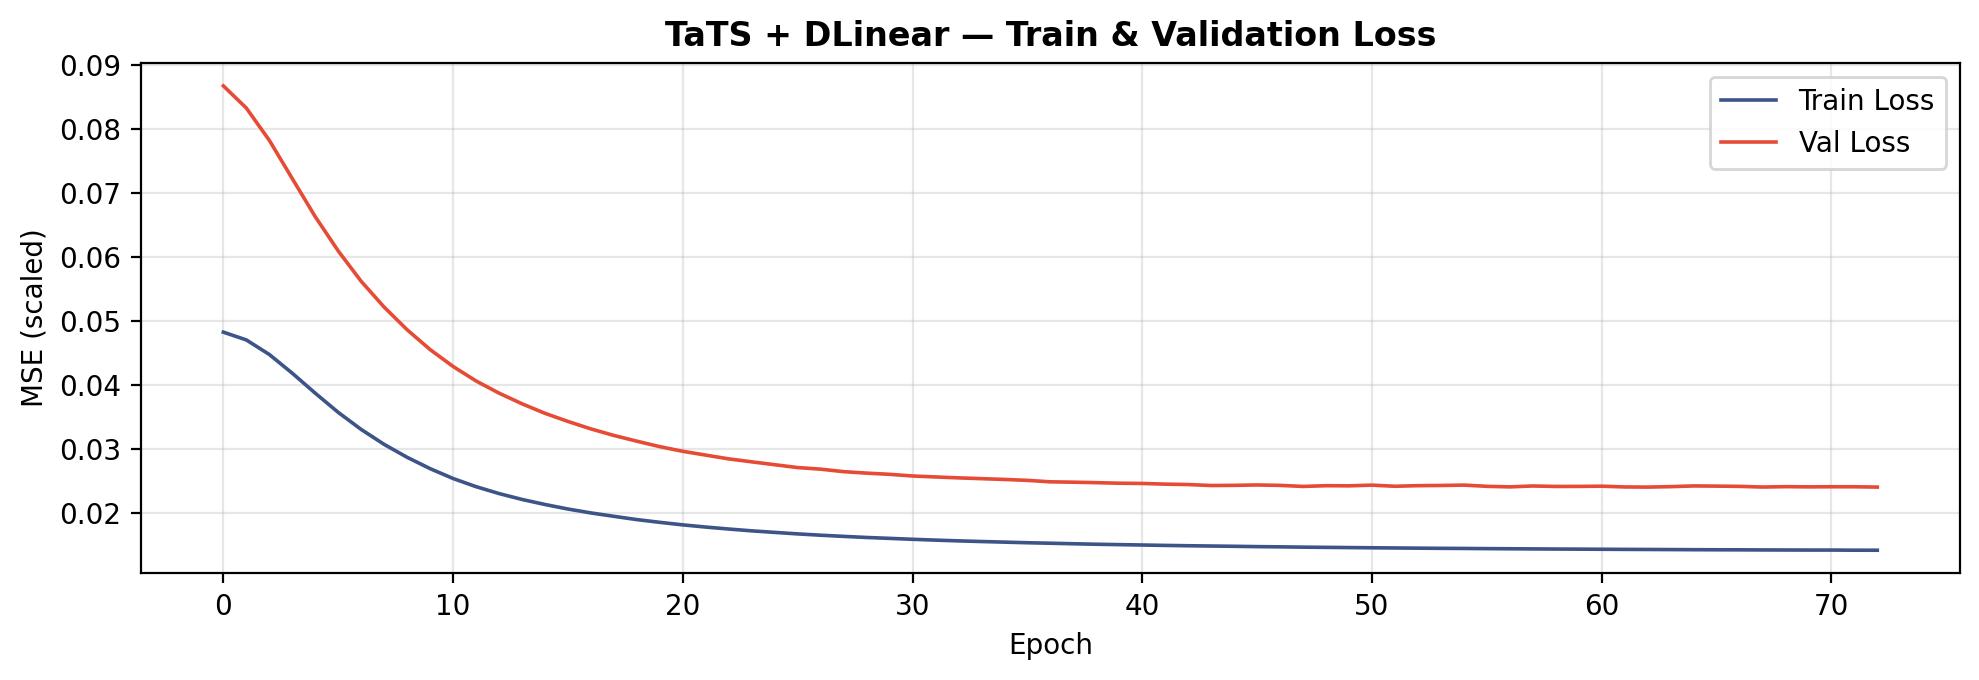

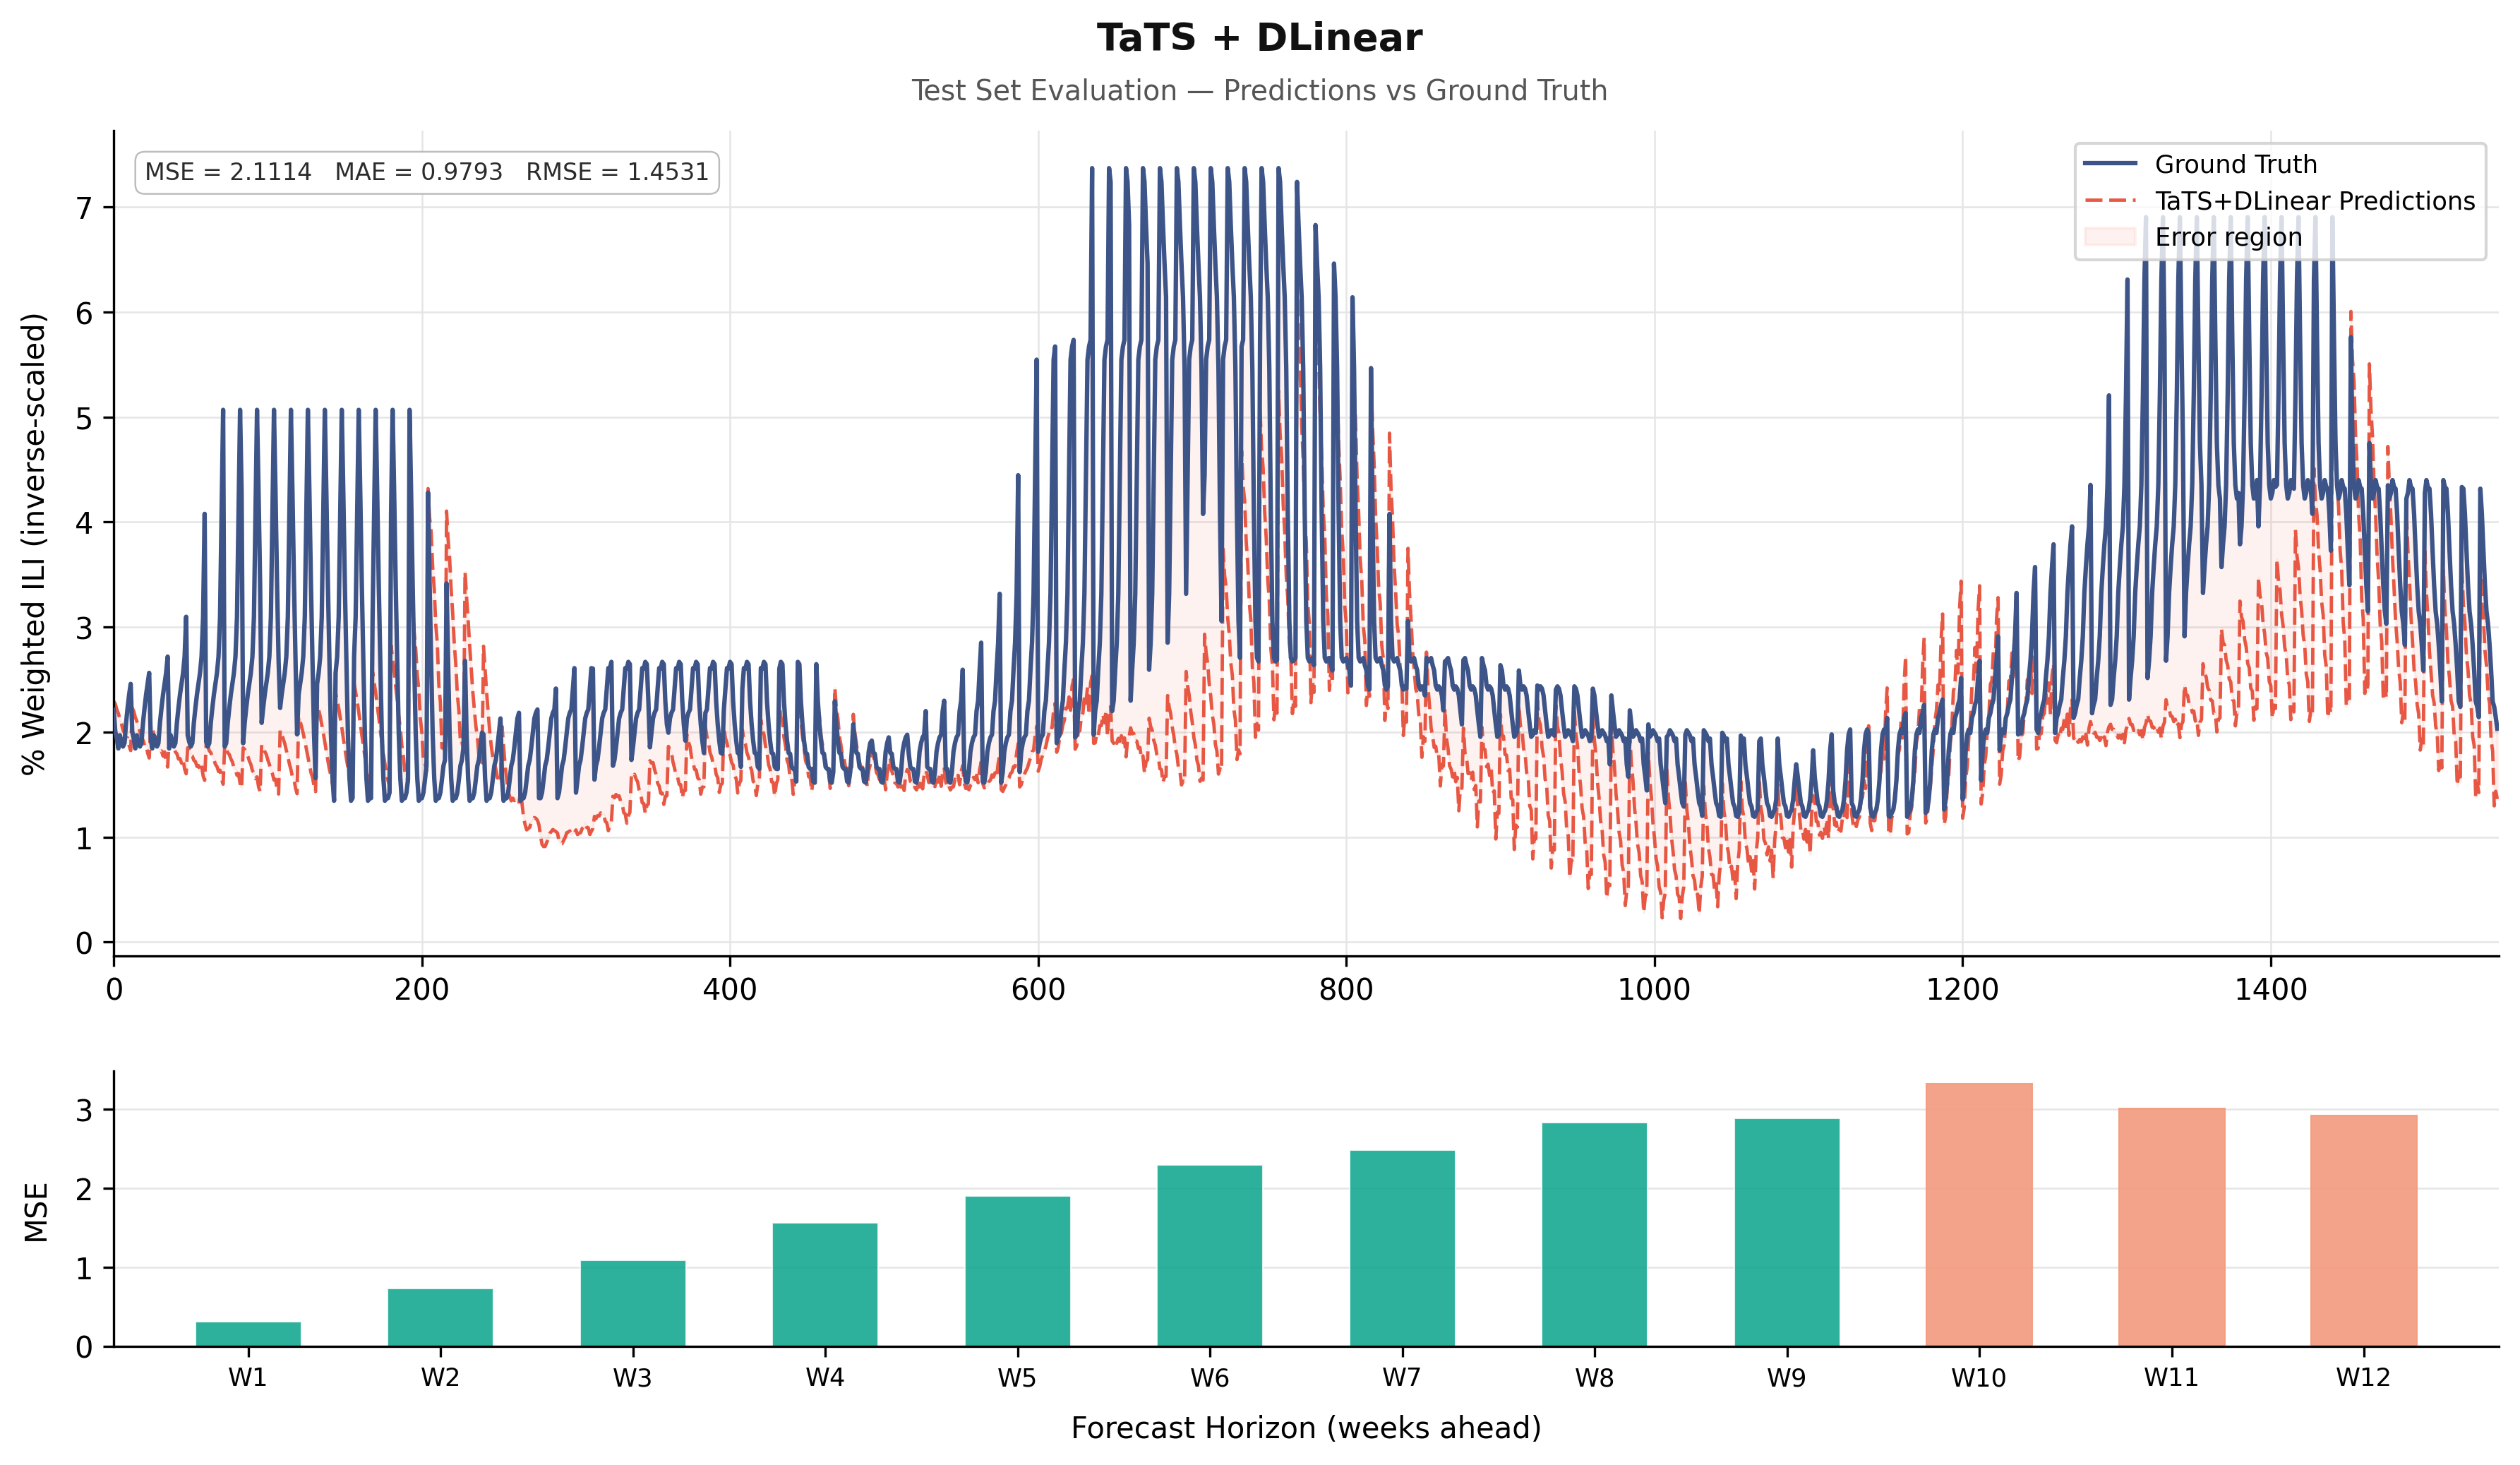


Training TaTS + PatchTST


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michiyasunaga/BioLinkBERT-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  1%|          | 1/120 [03:09<6:16:29, 189.82s/it]

[PatchTST] Epoch 0 | Train Loss: 0.062896 | Val Loss: 0.051176


  2%|▏         | 2/120 [06:21<6:14:53, 190.62s/it]

...

 28%|██▊       | 33/120 [1:44:38<4:34:39, 189.42s/it]

[PatchTST] Epoch 32 | Train Loss: 0.008200 | Val Loss: 0.030647


 28%|██▊       | 33/120 [1:47:46<4:44:09, 195.97s/it]

Early stopping at epoch 33



TaTS + PatchTST  |  Test MSE: 2.5416  MAE: 1.1697  RMSE: 1.5942


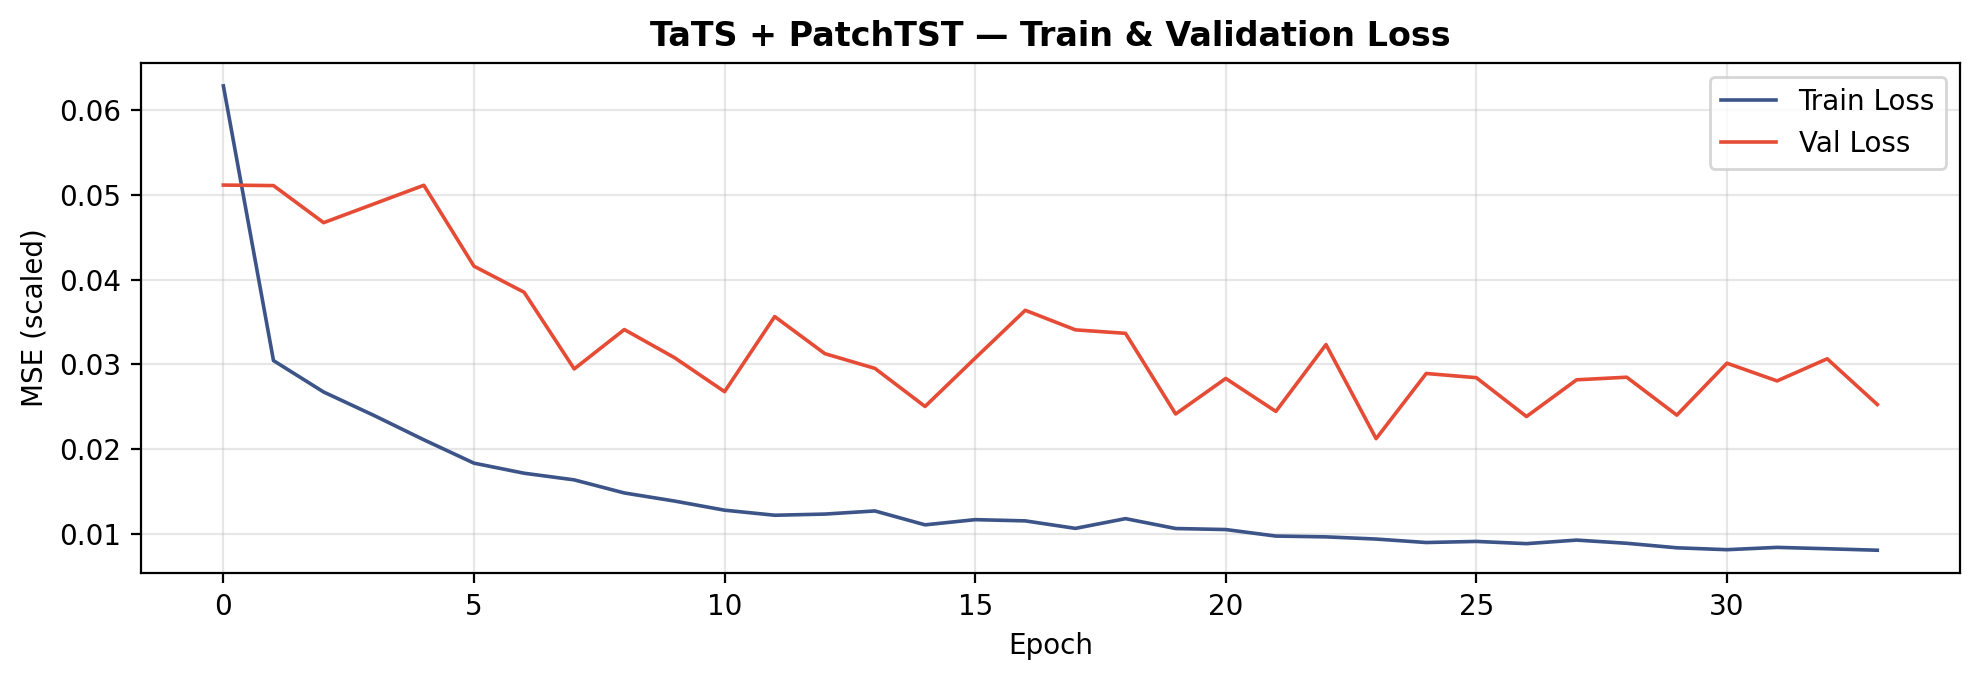

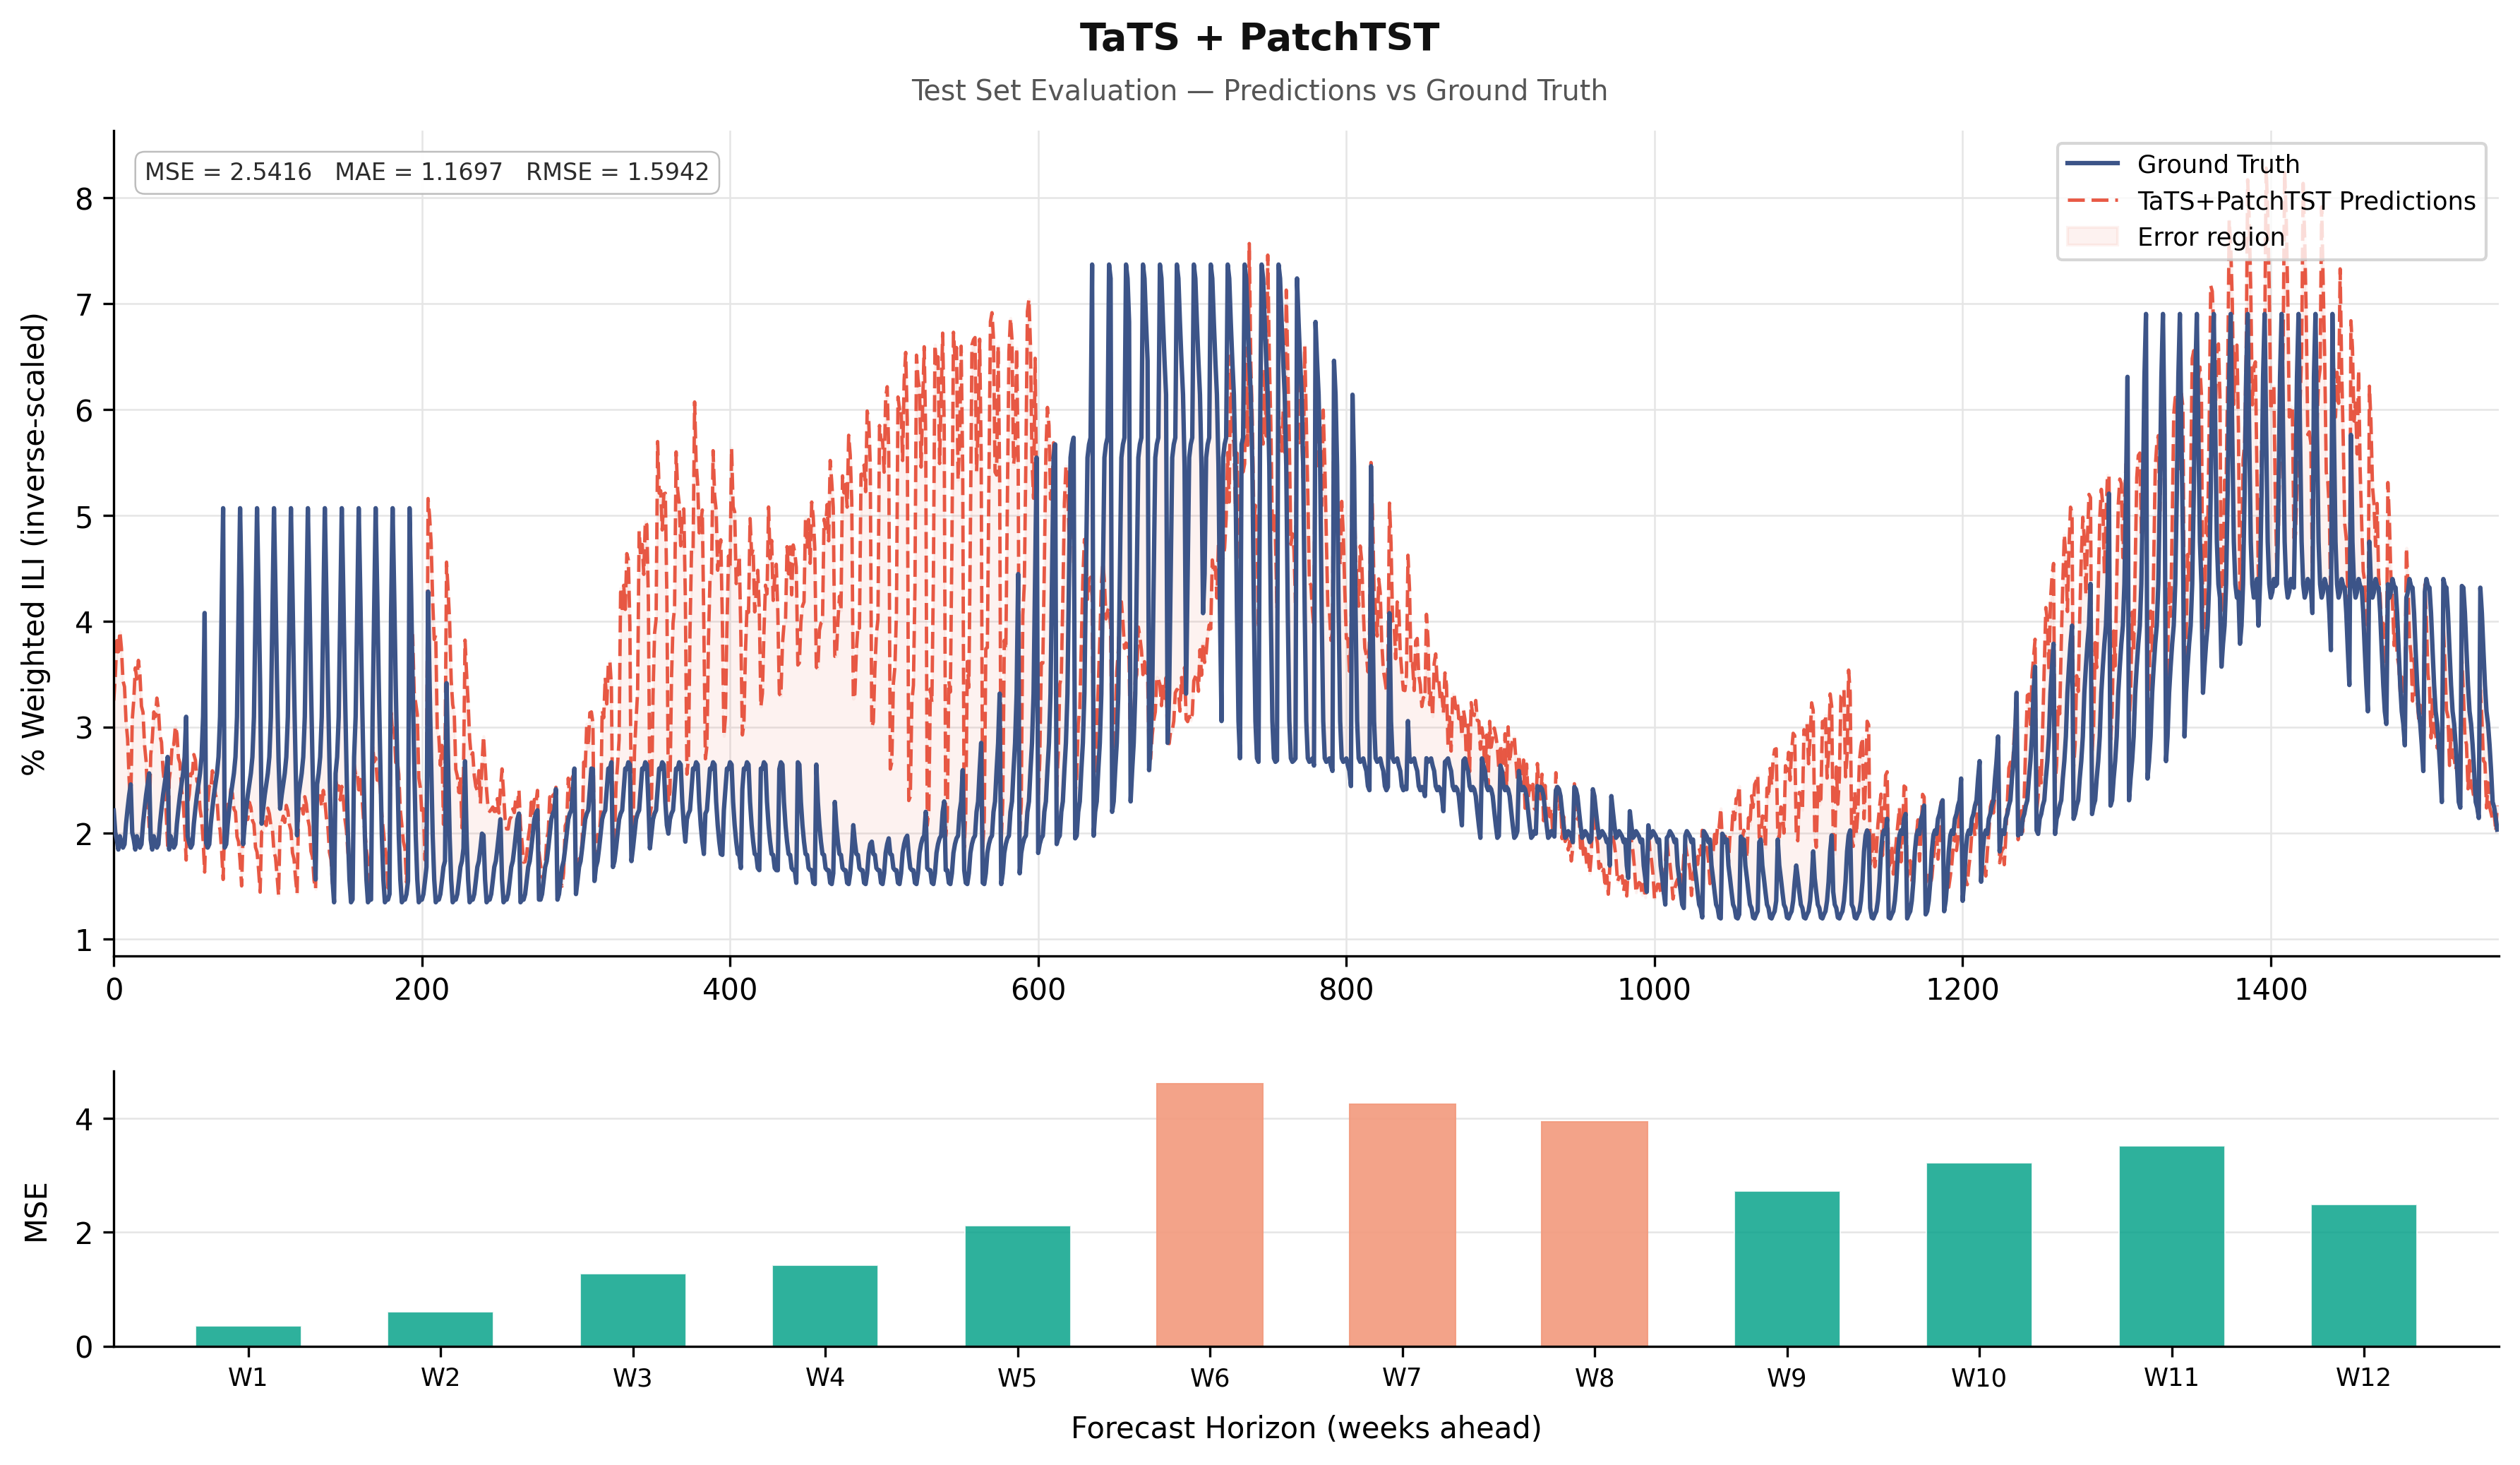


Training TaTS + iTransformer


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michiyasunaga/BioLinkBERT-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  1%|          | 1/120 [03:10<6:17:16, 190.22s/it]

[iTransformer] Epoch 0 | Train Loss: 0.046777 | Val Loss: 0.043826


  2%|▏         | 2/120 [06:21<6:15:04, 190.71s/it]

...

 16%|█▌        | 19/120 [1:00:19<5:21:03, 190.73s/it]

[iTransformer] Epoch 18 | Train Loss: 0.003267 | Val Loss: 0.028532


 16%|█▌        | 19/120 [1:03:29<5:37:31, 200.51s/it]

Early stopping at epoch 19



TaTS + iTransformer  |  Test MSE: 1.2772  MAE: 0.7625  RMSE: 1.1301


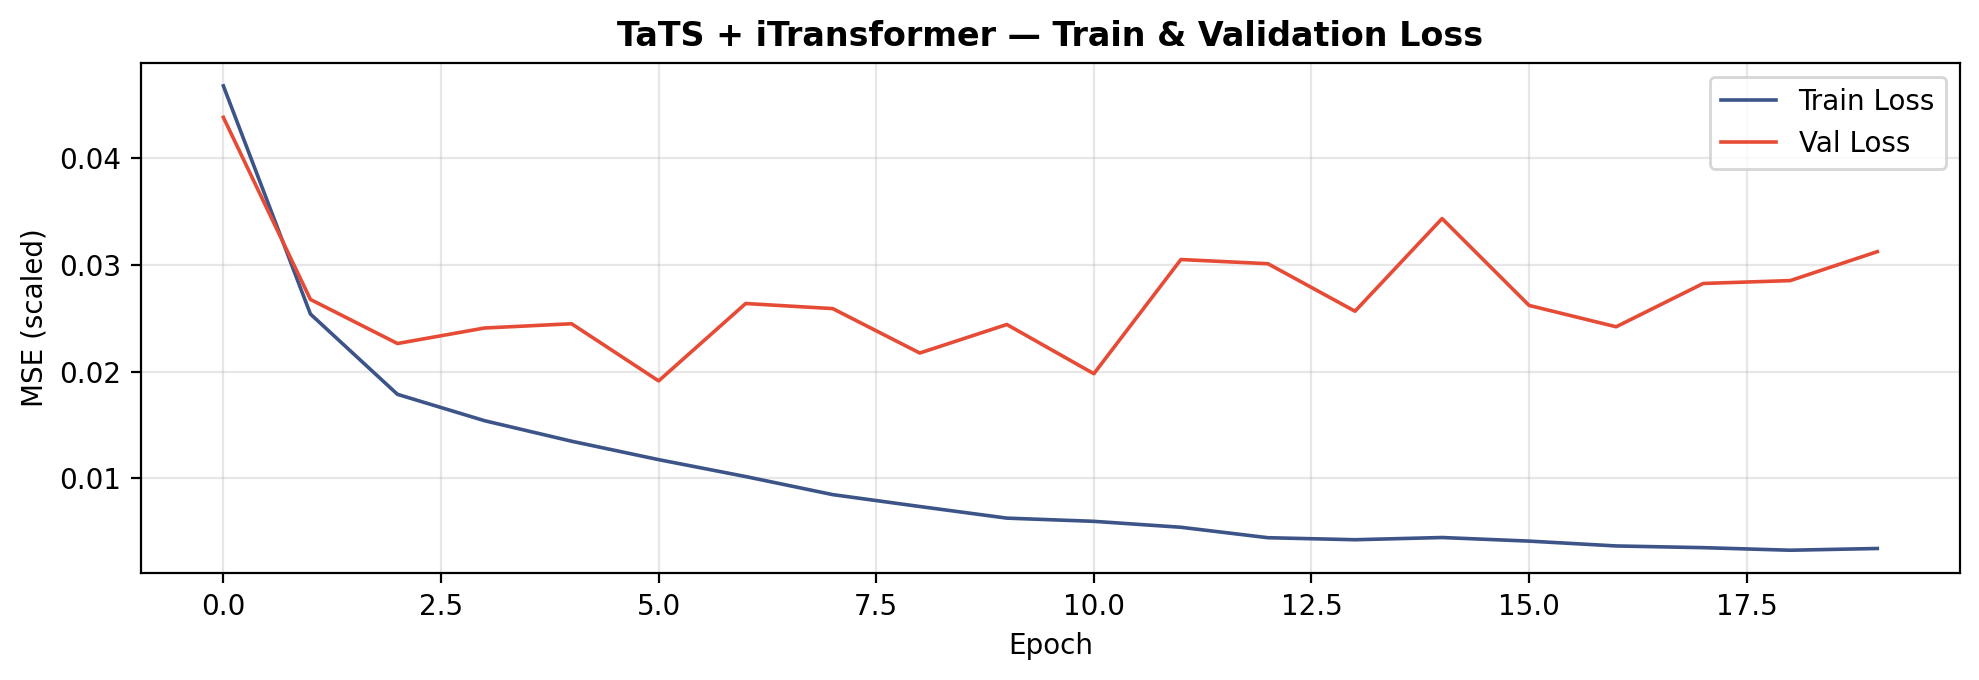

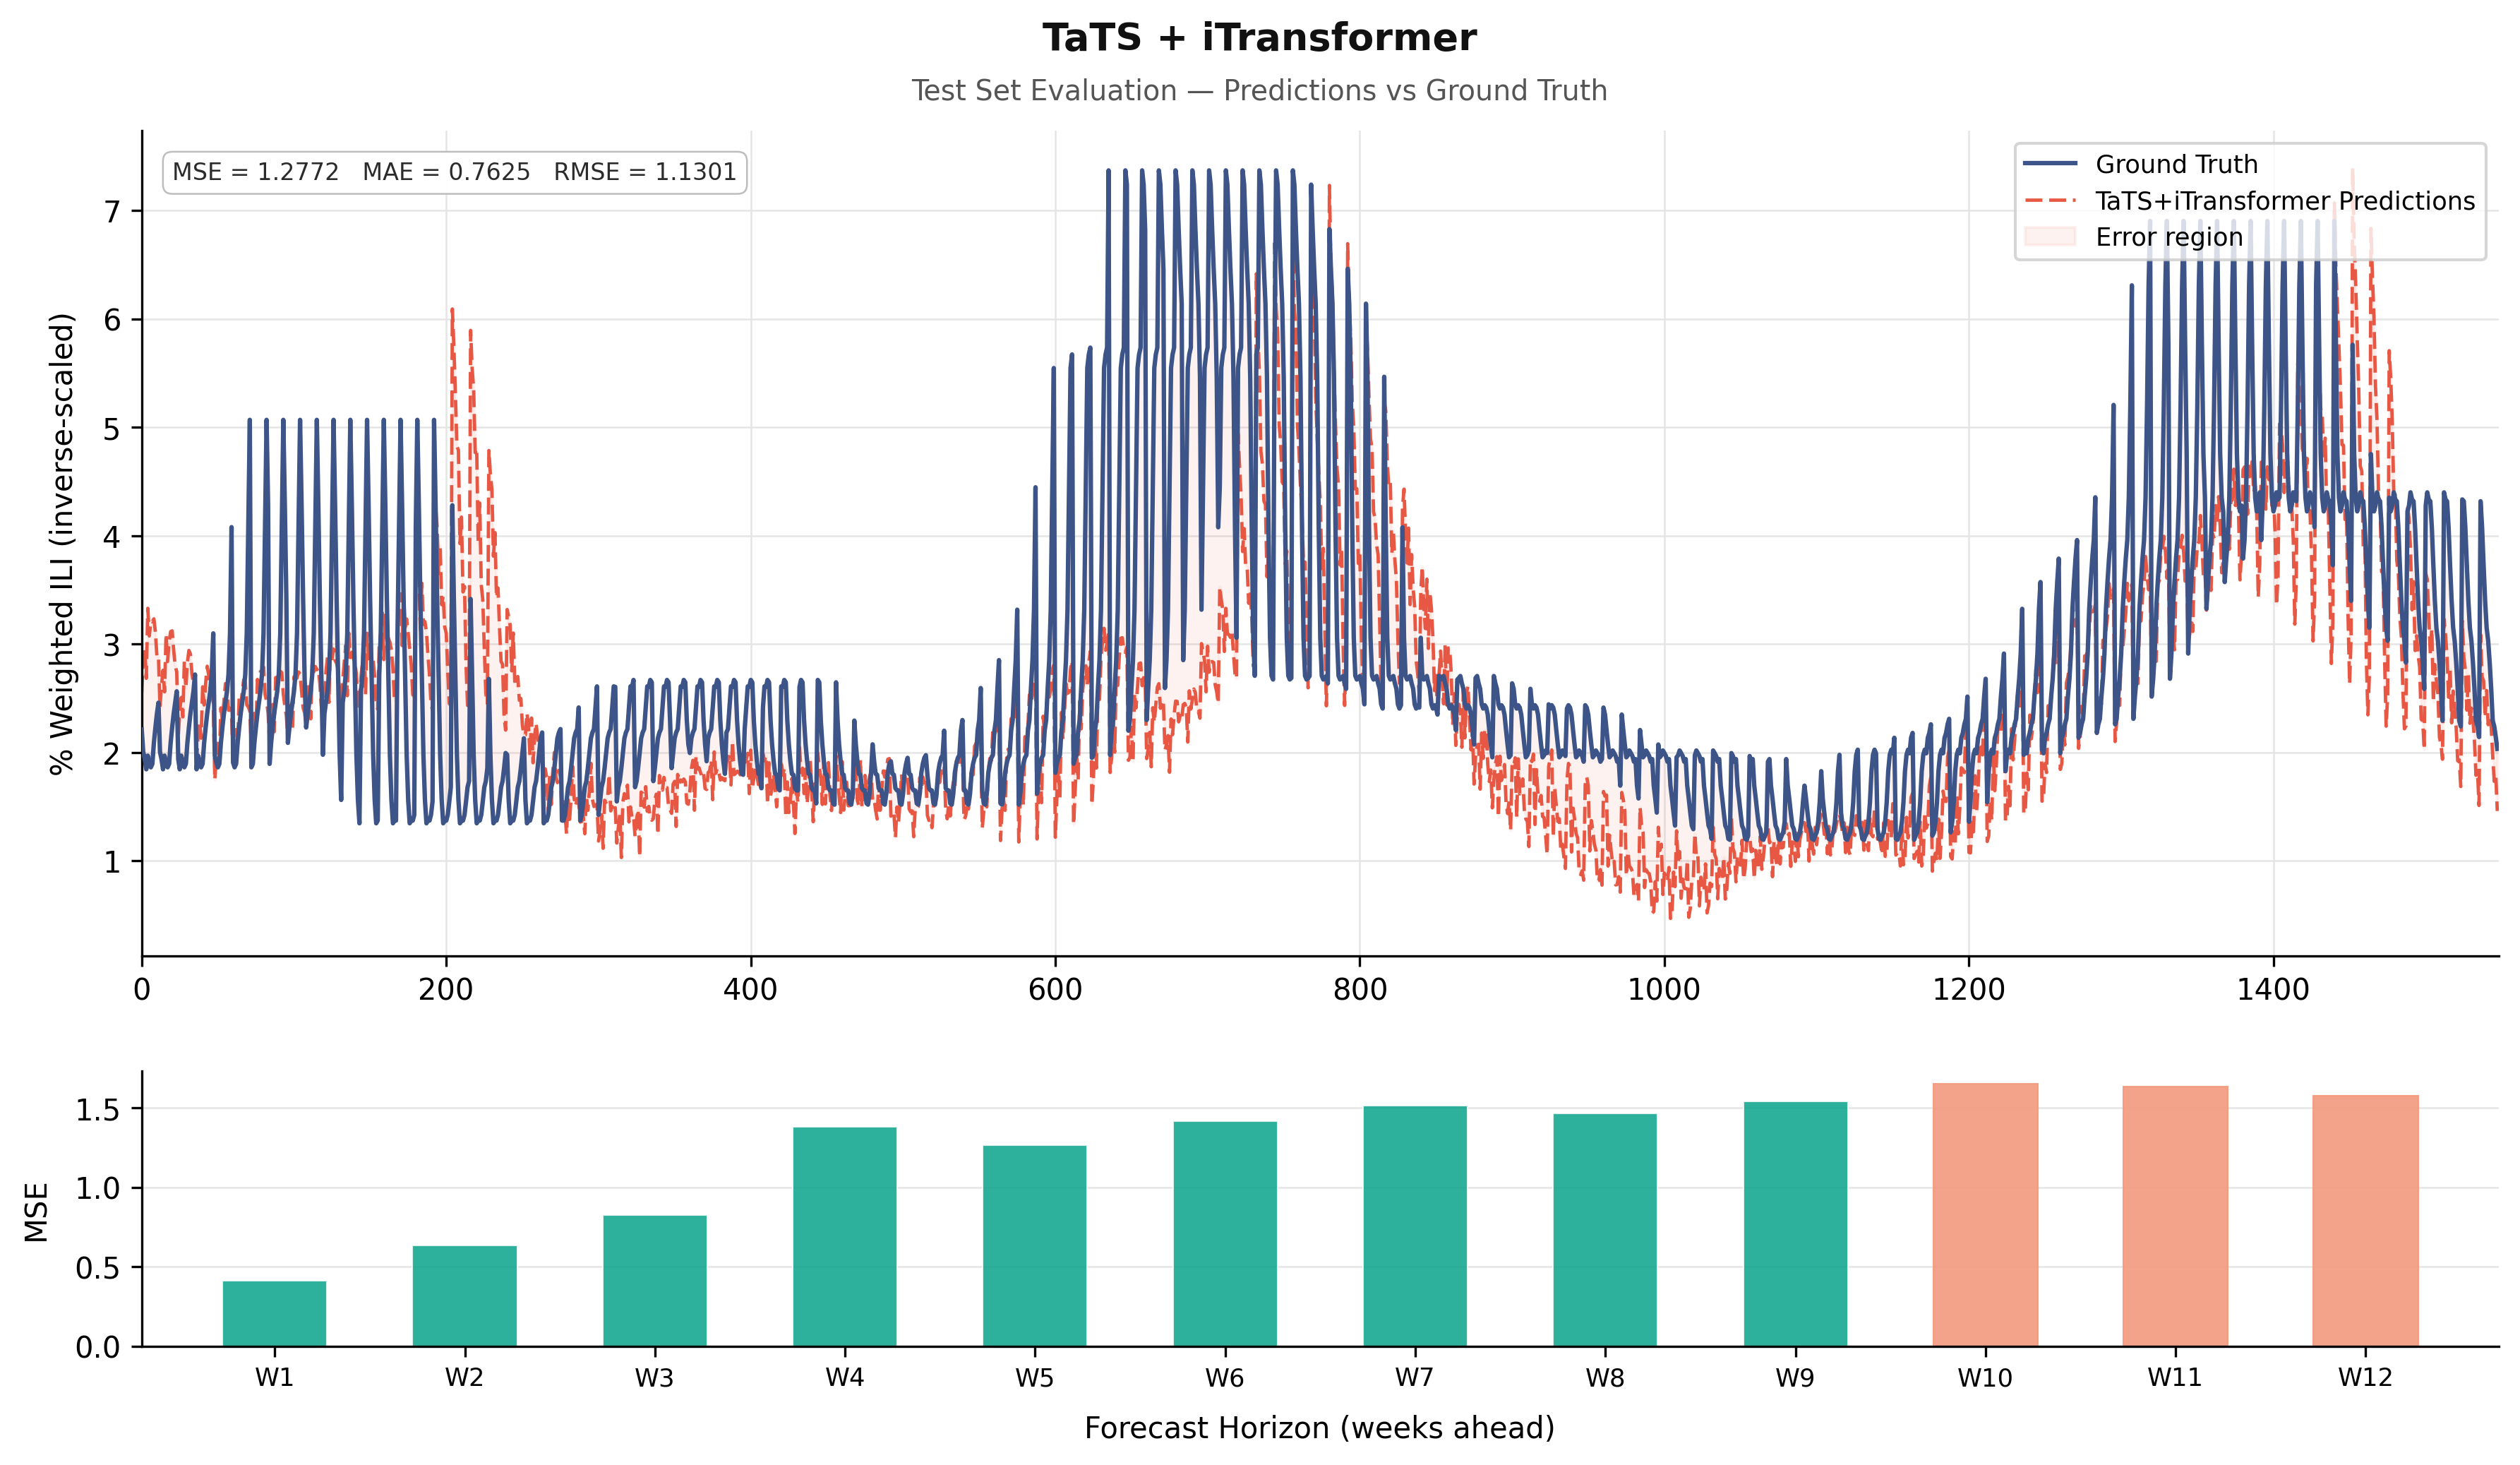

In [91]:
# Hyperparameters below are copied from what your naive-fusion notebooks
# *actually instantiated* (not always the same as their docstrings --
# see the PatchTST note above), so TaTS is compared against the identical
# backbone configuration used to produce your naive-fusion reference numbers.
BACKBONES = {
    'DLinear': lambda seq_len, horizon, num_channels: DLinearBackbone(
        seq_len, horizon, num_channels,
        kernel_size=25),

    'PatchTST': lambda seq_len, horizon, num_channels: PatchTSTBackbone(
        seq_len, horizon, num_channels,
        patch_len=4, stride=2, d_model=128, num_heads=8,
        num_layers=3, d_ff=256, dropout=0.15),

    'iTransformer': lambda seq_len, horizon, num_channels: iTransformerBackbone(
        seq_len, horizon, num_channels,
        d_model=512, num_heads=4, num_layers=3, d_ff=256, dropout=0.15),
}

results = {}
for name, ctor in BACKBONES.items():
    results[name] = run_tats_experiment(name, ctor, d_mapped=d_mapped)
    plot_tats_results(results[name])

# Performance Monitoring — Summary

In [92]:
print('=' * 70)
for name, r in results.items():
    print(f'  TaTS + {name:<13} | Test MSE: {r["mse"]:.4f}  MAE: {r["mae"]:.4f}  RMSE: {r["rmse"]:.4f}')
print('-' * 70)
print(f'  DSA - MultiModal        | Test MSE : (fill in from your DSA run)')
print(f'  DSA - UniModal          | Test MSE : 1.0852 (ref)')
print(f'  PatchTST+BERT naive     | Test MSE : 2.9825 (ref)')
print(f'  iTransformer+BERT naive | Test MSE : 2.4165 (ref)')
print(f'  DLinear+BERT naive      | Test MSE : 2.2620 (ref)')
print(f'  DSA (mean / best)       | Test MSE : 1.120 ± 0.096 / 0.9749')
print('=' * 70)
print()
print('NOTE: naive-fusion and DSA reference numbers above are copied from')
print('your DSA notebook\'s own printout -- update the DSA line with your')
print('actual run\'s number once available.')

  TaTS + DLinear       | Test MSE: 2.1114  MAE: 0.9793  RMSE: 1.4531
  TaTS + PatchTST      | Test MSE: 2.5416  MAE: 1.1697  RMSE: 1.5942
  TaTS + iTransformer  | Test MSE: 1.2772  MAE: 0.7625  RMSE: 1.1301
----------------------------------------------------------------------
  DSA - MultiModal        | Test MSE : (fill in from your DSA run)
  DSA - UniModal          | Test MSE : 1.0852 (ref)
  PatchTST+BERT naive     | Test MSE : 2.9825 (ref)
  iTransformer+BERT naive | Test MSE : 2.4165 (ref)
  DLinear+BERT naive      | Test MSE : 2.2620 (ref)
  DSA (mean / best)       | Test MSE : 1.120 ± 0.096 / 0.9749

NOTE: naive-fusion and DSA reference numbers above are copied from
your DSA notebook's own printout -- update the DSA line with your
actual run's number once available.


In [93]:
# !rm -rf /kaggle/working/*